## EEE205 Artificial Intelligence I
# Part 13 - Classification
## Tutorial
### Barry Dillon

**1 - In your own words, write down a definition of each of these concepts.**

Look at the terms below and try to explain what they are and why they are used.  First from memory, without checking notes or the internet.  Then check your notes/internet to improve what you have.  This is a good learning technique.

1- The Sigmoid function

The **sigmoid function** is a smooth S‑shaped function that maps any real number to a value between 0 and 1.  
In classification it is used to turn a model’s raw score (the *logit*) into a probability for the positive class.

Mathematically it is  

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

If \(z\) is very negative, \(\sigma(z)\approx 0\); if \(z\) is very positive, \(\sigma(z)\approx 1\).  
Because it is differentiable everywhere and outputs values in \([0,1]\), it is ideal for binary classification and for training with gradient descent.


2 - The Softmax function

The **softmax function** is a generalisation of the sigmoid to more than two classes.  
It takes a vector of raw scores (logits) for each class and converts them into a probability distribution over classes.

For scores \(z_1, z_2, \dots, z_K\), softmax is

\[
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
\]

Every output is between 0 and 1 and all outputs sum to 1.  
In multi‑class classification, the largest softmax value corresponds to the predicted class, and the values themselves can be interpreted as class probabilities.


3 - Binary vs multi-class classification

In **binary classification** there are only two possible classes (e.g. *spam vs not‑spam*, *disease vs no disease*).  
The model typically outputs a single score or probability for the “positive” class, often using a sigmoid function.

In **multi‑class classification** there are three or more possible classes (e.g. the three iris species).  
The model outputs a separate score for each class, and a softmax layer is often used to turn these scores into probabilities.  
The predicted label is the class with the highest probability.  
So: binary = 2 classes, multi‑class = 3 or more classes.


4 - Decision boundary

A **decision boundary** is the surface (a line in 2D, a plane in 3D, or a higher‑dimensional surface) that separates regions of the feature space where the classifier predicts different classes.

For example, in 2D with two classes, the decision boundary is the curve where the model is exactly undecided between the two classes (e.g. predicted probability = 0.5).  
Points on one side of the boundary are classified as class A; points on the other side are classified as class B.


5 - Accuracy

**Accuracy** is the fraction of examples that the classifier gets correct.

If a model makes predictions on \(N\) data points, and it correctly classifies \(N_{\text{correct}}\) of them, then

\[
\text{accuracy} = \frac{N_{\text{correct}}}{N}.
\]

It is a simple and widely used metric for classification performance, especially when all classes are equally important and the dataset is reasonably balanced.


**2 - Binary classification with the Iris dataset using logistic regression**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
# Load the iris dataset
iris = load_iris()

# Features and target
X = iris.data  # shape (150, 4)
y = iris.target  # shape (150,)

print('Feature names:', iris.feature_names)
print('Target names:', iris.target_names)
print('X shape:', X.shape)
print('y shape:', y.shape)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


In [3]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y

1 - Do a basic exploration of the dataset using pandas.

In [4]:
# Basic exploration of the dataset
print(df.head())            # first few rows
print()
print(df.describe())        # summary statistics of the features
print()
print(df['species'].value_counts())  # how many examples of each class


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.3

2 - The code below creates masks that index only the Setosa and Versicolor classes.  Comment the code and explain what is happening.

In [5]:
# Create boolean masks for the different classes
# In the iris dataset the targets are encoded as:
#   0 -> setosa, 1 -> versicolor, 2 -> virginica
mask_setosa = (y == 0)          # True for samples that are setosa
mask_versicolor = (y == 1)      # True for samples that are versicolor

# Mask selecting only the two classes we will use (setosa and versicolor)
mask_twoclass = mask_setosa | mask_versicolor


3 - Finish the code below to make a scatter plot of the petal length (x-axis) vs petal width (y-axis) features showing the datapoints belonging to each class separately.  Comment the code to explain what is happening.  Hint:  use the masks, check how to index numpy arrays.

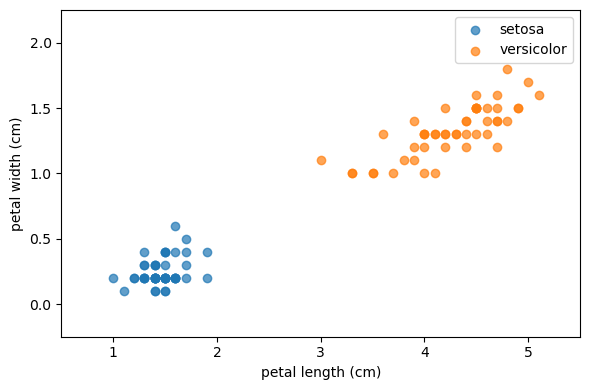

In [6]:
plt.figure(figsize=(6, 4))

# Plot petal length (feature 2) vs petal width (feature 3) for the two classes
plt.scatter(
    X[mask_setosa, 2], X[mask_setosa, 3],
    label='setosa', alpha=0.7
)
plt.scatter(
    X[mask_versicolor, 2], X[mask_versicolor, 3],
    label='versicolor', alpha=0.7
)

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')

plt.ylim(-0.25, 2.25)
plt.xlim(0.5, 5.5)
plt.legend()
plt.tight_layout()
plt.show()


3 - Use the masks to index the original dataset `X` and it's labels `y`, call the new dataset and labels `X_tc` and `y_tc`, `tc` stands for 'two class'.

In [7]:
X_tc = X[mask_twoclass]


In [8]:
y_tc = y[mask_twoclass]


4 - Check the shape of the features, now restrict the features to just two, the petal length and petal width.

In [9]:
# Check the shape before restricting to two features
print('X_tc shape before feature selection:', X_tc.shape)


X_tc shape before feature selection: (100, 4)


In [10]:
# Keep only petal length (index 2) and petal width (index 3)
X_tc = X_tc[:, 2:4]


In [11]:
# Check the new shape (should have 2 feature columns)
print('X_tc shape after feature selection:', X_tc.shape)


X_tc shape after feature selection: (100, 2)


5 - Create a train/test split with 80/20 in the data.  Name the feature variables `X_train` and `X_test`, and the labels `y_train` and `y_test`.

In [12]:
# 80/20 train–test split for the two-class problem
X_train, X_test, y_train, y_test = train_test_split(
    X_tc, y_tc, test_size=0.2, random_state=0, stratify=y_tc
)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)


X_train shape: (80, 2)
X_test  shape: (20, 2)
y_train shape: (80,)
y_test  shape: (20,)


6 - The code below initialises the model.  Finish the second line to perform the fit:

In [13]:
# Initialise and fit the logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)    # fit on the training data


LogisticRegression(max_iter=1000)

7 - Complete the code below to make predictions for the train and test data.  Hint: use `model.predict()`.

In [14]:
y_train_pred = model.predict(X_train)


In [15]:
y_test_pred = model.predict(X_test)


8 - Complete the code below to compute the accuracies.  Look up the syntax for using the `accuracy_score()` function, it's similar to the mse score and r2 score.

In [16]:
# Compute accuracy on the training and test sets
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f'Training accuracy: {train_acc:.3f}')
print(f'Test accuracy:     {test_acc:.3f}')


Training accuracy: 1.000
Test accuracy:     1.000


Is this a good model?

The code below computes and plots the decision boundary on top of the scatter plot, to help visualise how the logistic regression classifier that we trained makes its decision.  Read and understand this code carefully.

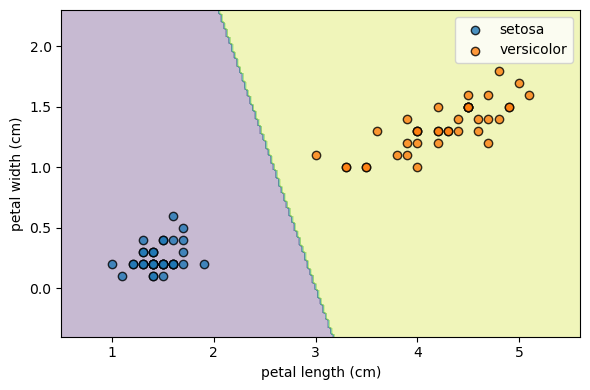

In [17]:
# Create a grid of points covering the feature space (two-class model)
x_min, x_max = X_tc[:, 0].min() - 0.5, X_tc[:, 0].max() + 0.5
y_min, y_max = X_tc[:, 1].min() - 0.5, X_tc[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict class for each point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 4))

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Overlay the training points
mask_setosa_train = (y_train == 0)
mask_versicolor_train = (y_train == 1)

plt.scatter(X_train[mask_setosa_train, 0], X_train[mask_setosa_train, 1],
            label='setosa', edgecolor='k', alpha=0.8)
plt.scatter(X_train[mask_versicolor_train, 0], X_train[mask_versicolor_train, 1],
            label='versicolor', edgecolor='k', alpha=0.8)

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)
plt.legend()
plt.tight_layout()
plt.show()


9 - Compare this plot to the accuracy score you got before.

**3 - Binary classification with the Iris dataset using logistic regression**

Here you should do the exact same analysis from the previous question, but for all three classes of the data.  The steps are outlined below.

1 - Make a scatter plot showing all three classes.  Check with the plot from the lecture to see if it matches.  Edit the `(x,y)` limits if you need to.

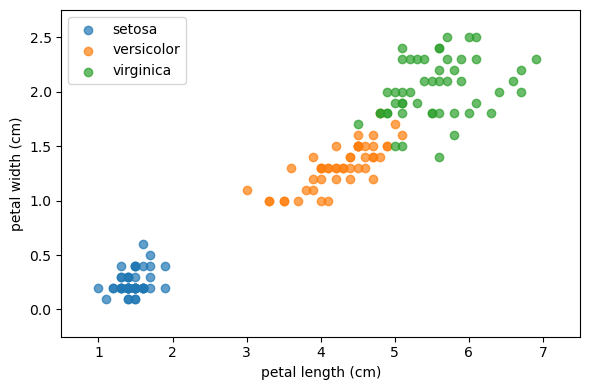

In [18]:
plt.figure(figsize=(6, 4))

# Scatter plot of all three classes using petal length vs petal width
for class_idx, class_name in enumerate(iris.target_names):
    plt.scatter(
        X[y == class_idx, 2],
        X[y == class_idx, 3],
        alpha=0.7,
        label=class_name
    )

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.ylim(-0.25, 2.75)
plt.xlim(0.5, 7.5)
plt.legend()
plt.tight_layout()
plt.show()


2 - Restrict `X` to the two features for petal length and petal width.

In [19]:
# Use only petal length and petal width as features
X_2f = X[:, 2:4]
print('X_2f shape:', X_2f.shape)


X_2f shape: (150, 2)


3 - Make an 80/20 split in the data for all three classes.  Check the shapes of the new data. 

In [20]:
# 80/20 train–test split for all three classes
X_train_3c, X_test_3c, y_train_3c, y_test_3c = train_test_split(
    X_2f, y, test_size=0.2, random_state=0, stratify=y
)

print('X_train_3c shape:', X_train_3c.shape)
print('X_test_3c  shape:', X_test_3c.shape)
print('y_train_3c shape:', y_train_3c.shape)
print('y_test_3c  shape:', y_test_3c.shape)


X_train_3c shape: (120, 2)
X_test_3c  shape: (30, 2)
y_train_3c shape: (120,)
y_test_3c  shape: (30,)


4 - Initialise and fit a new logistic regression model.

In [21]:
# Initialise and fit a logistic regression model for three classes
model_3c = LogisticRegression(max_iter=1000, multi_class='auto')
model_3c.fit(X_train_3c, y_train_3c)


C:\Users\Mariam\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='auto')

5 - Calculate the predicted labels for train and test data.

In [22]:
# Predicted labels for train and test data (three-class model)
y_train_pred_3c = model_3c.predict(X_train_3c)
y_test_pred_3c = model_3c.predict(X_test_3c)


6 - Calculate the train and test accuracies.  How do they compare to before?

In [23]:
# Train and test accuracies for the three-class model
train_acc_3c = accuracy_score(y_train_3c, y_train_pred_3c)
test_acc_3c = accuracy_score(y_test_3c, y_test_pred_3c)

print(f'Training accuracy (3 classes, 2 features): {train_acc_3c:.3f}')
print(f'Test accuracy     (3 classes, 2 features): {test_acc_3c:.3f}')


Training accuracy (3 classes, 2 features): 0.950
Test accuracy     (3 classes, 2 features): 1.000


7 - Plot the decision boundaries on top of the scatter plots.  Can you understand the change in accuracy from this plot?

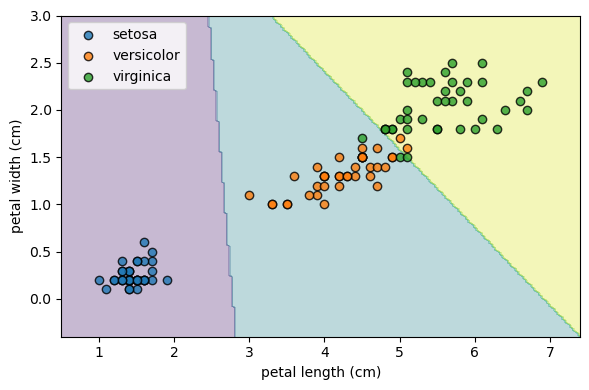

In [24]:
# Decision boundaries for the three-class model (using two features)
x_min, x_max = X_2f[:, 0].min() - 0.5, X_2f[:, 0].max() + 0.5
y_min, y_max = X_2f[:, 1].min() - 0.5, X_2f[:, 1].max() + 0.5

xx_3c, yy_3c = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_points_3c = np.c_[xx_3c.ravel(), yy_3c.ravel()]
Z_3c = model_3c.predict(grid_points_3c)
Z_3c = Z_3c.reshape(xx_3c.shape)

plt.figure(figsize=(6, 4))

# Filled contour plot of decision regions
plt.contourf(xx_3c, yy_3c, Z_3c, alpha=0.3)

# Overlay the training data
for class_idx, class_name in enumerate(iris.target_names):
    plt.scatter(
        X_train_3c[y_train_3c == class_idx, 0],
        X_train_3c[y_train_3c == class_idx, 1],
        alpha=0.8,
        edgecolor='k',
        label=class_name
    )

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.ylim(y_min, y_max)
plt.xlim(x_min, x_max)
plt.legend()
plt.tight_layout()
plt.show()


**4 - Repeat the above analysis, but using all four features.  You won't be able to plot all four features at once, so we can't visualise the decision boundary.  But you can compare the accuracies of this model with the previous model using two features.**

In [25]:
# Logistic regression using all four features
X_all = X  # all four original features

X_train_4f, X_test_4f, y_train_4f, y_test_4f = train_test_split(
    X_all, y, test_size=0.2, random_state=0, stratify=y
)

model_4f = LogisticRegression(max_iter=1000, multi_class='auto')
model_4f.fit(X_train_4f, y_train_4f)

y_train_pred_4f = model_4f.predict(X_train_4f)
y_test_pred_4f = model_4f.predict(X_test_4f)

train_acc_4f = accuracy_score(y_train_4f, y_train_pred_4f)
test_acc_4f = accuracy_score(y_test_4f, y_test_pred_4f)

print(f'Training accuracy (3 classes, 4 features): {train_acc_4f:.3f}')
print(f'Test accuracy     (3 classes, 4 features): {test_acc_4f:.3f}')


Training accuracy (3 classes, 4 features): 0.967
Test accuracy     (3 classes, 4 features): 1.000


C:\Users\Mariam\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
